# Decision Tree
-------------
## A Decision Tree is a supervised learning algorithm used for classification and regression. It recursively splits the dataset using the feature and threshold that best separate the data, producing a tree-like structure where leaf nodes represent the final prediction.

#### Algorithm Steps
#### 1. Start with the entire dataset.
#### 2. Check the stopping conditions.
#### 3. Find the best feature and threshold to split the data.
#### 4. Split the dataset into left and right subsets.
#### 5. Repeat the process recursively for each subset.
#### 6. Create a leaf node when a stopping condition is met.
#### 7. Predict by traversing the tree from the root to a leaf.

In [10]:
import torch
torch.manual_seed(42)

# Create Dataset

In [11]:
# Number of samples per class
n_samples = 100

# Generate three classes
class_0 = torch.randn(n_samples, 2) + torch.tensor([-3.0, -3.0])
class_1 = torch.randn(n_samples, 2) + torch.tensor([ 3.0, -3.0])
class_2 = torch.randn(n_samples, 2) + torch.tensor([ 0.0,  3.0])

# Combine features
X = torch.cat((class_0, class_1, class_2), dim=0)

# Create labels
y = torch.cat((
    torch.zeros(n_samples),
    torch.ones(n_samples),
    torch.full((n_samples,), 2)
)).long()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", torch.unique(y))

X shape: torch.Size([300, 2])
y shape: torch.Size([300])
Classes: tensor([0, 1, 2])


# Entropy or Gini Impurity
## Entropy/Gini answers: "How mixed are the labels in this node?"
### A node is simply a subset of the dataset at any stage of building the tree.

Initially, all training samples belong to the Root Node.

                Root Node
              (300 samples)

After the best split:

             Root Node
          Feature0 <= 1.5
           /            \
      Left Node      Right Node
    (180 samples)   (120 samples)

Each node contains a subset of the original data, and Entropy/Gini is calculated on the labels (y) of that node.

# Entropy

### Entropy is a measure of the uncertainty or impurity of the labels in a node. A lower entropy means the node is purer, while a higher entropy means the classes are more mixed.

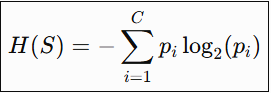

#### C = number of classes
#### pi = probability of class i

#### Example:
#### Labels: 0 0 1 1
#### Prob(0) = 0.5, Prob(1) = 0.5
#### H = -(0.5log₂0.5 + 0.5log₂0.5) = 1 (Maximum impurity for two class)

In [19]:
class Probability:
    def __call__(self, labels):
        unique, counts = torch.unique(labels, return_counts=True)
        probabilities = counts.float() / len(labels)
        return unique, probabilities

In [20]:
p = Probability()
p(torch.tensor([1,1,2,0]))

(tensor([0, 1, 2]), tensor([0.2500, 0.5000, 0.2500]))

In [16]:
class Entropy:
    def __init__(self):
        self.probability = Probability()

    def __call__(self, labels):
        _, p = self.probability(labels)
        p_log2 = torch.tensor([i * torch.log2(i) for i in p])
        return -torch.sum(p_log2)

# Gini Impurity

### Gini Impurity measures how likely it is to incorrectly classify a randomly chosen sample if labels are assigned according to the class distribution.

#### Suppose a node contains these labels: [0 0 0 0]. If I randomly pick a sample from this node, what class do you think it is? Obviously class 0. There is no confusion, so node is pure, Gini=0

#### Now consider this node: [0 0 0 1]. 75% of samples are Class 0 and 25% are Class 1. If you had to guess the class of a randomly selected sample, you'd probably guess Class 0. Most of the time you'd be right.

#### Now consider this node : [0 0 1 1]. Here the probabilities are equal: Class 0 (50%) and Class 1 (50%). There is maximum confusion so Gini is high.

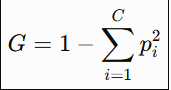

In [17]:
class GiniImpurity:
    def __init__(self):
        self.probability = Probability()

    def __call__(self, labels):
        _, p = self.probability(labels)
        s = torch.tensor([i ** 2 for i in p])
        return 1 - torch.sum(s)

## Information Gain (IG)

### Information Gain measures how much a split reduces the impurity of a node. It is calculated as the difference between the impurity of the parent node and the weighted impurity of its child nodes. The split with the highest Information Gain is selected by the Decision Tree.
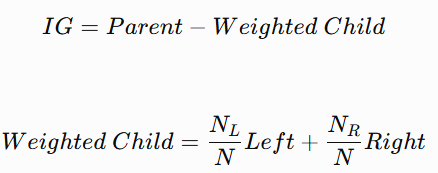
### IG = Parent Impurity − Weighted Child Impurity

#### Weighted Child Impurity = (Left Samples / Total Samples) × Left Impurity + (Right Samples / Total Samples) × Right Impurity

In [21]:
class InformationGain:
    def __init__(self, strategy: str = "entropy"):
        self.strategy = strategy.lower()
        if self.strategy == "gini":
            self.criterion = GiniImpurity()
        elif self.strategy == "entropy":
            self.criterion = Entropy()
        else:
            raise ValueError("Strategy must be either 'entropy' or 'gini'.")

    def __call__(self, parent_labels, left_labels, right_labels):
        parent_impurity = self.criterion(parent_labels)
        left_weight = len(left_labels) / len(parent_labels)
        right_weight = len(right_labels) / len(parent_labels)
        child_impurity = (
            left_weight * self.criterion(left_labels)
            + right_weight * self.criterion(right_labels)
        )

        return parent_impurity - child_impurity

# Split Dateset

In [22]:
class SplitDataset:
    def __call__(self, X, y, feature_idx, threshold):
        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask

        X_left = X[left_mask]
        y_left = y[left_mask]

        X_right = X[right_mask]
        y_right = y[right_mask]

        return X_left, y_left, X_right, y_right

# Best Split

In [ ]:
class BestSplit:
    def __init__(self, strategy="entropy"):
        self.split_dataset = SplitDataset()
        self.information_gain = InformationGain(strategy)

    def __call__(self, X, y):

        best_gain = -float("inf")
        best_feature = None
        best_threshold = None
        best_split = None

        n_features = X.shape[1]

        for feature_idx in range(n_features):

            thresholds = torch.unique(X[:, feature_idx])

            for threshold in thresholds:

                X_left, y_left, X_right, y_right = self.split_dataset(
                    X,
                    y,
                    feature_idx,
                    threshold
                )

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gain = self.information_gain(y, y_left, y_right)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
                    best_split = (X_left, y_left, X_right, y_right)

        return best_feature, best_threshold, best_gain, best_split

# Node

In [ ]:
class Node:
    def __init__(self,feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    @property
    def is_leaf(self):
        return self.value is not None

# Decision Tree

In [28]:
class DecisionTree:

    def __init__(self, max_depth=10, min_samples_split=2, strategy="entropy"):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.best_split = BestSplit(strategy)
        self.root = None

    def _build_tree(self, X, y, depth=0):

        # Stop if all labels are same
        if len(torch.unique(y)) == 1:
            return Node(value=y[0].item())

        # Maximum depth
        if depth >= self.max_depth:
            value = torch.mode(y).values.item()
            return Node(value=value)

        # Minimum samples
        if len(y) < self.min_samples_split:
            value = torch.mode(y).values.item()
            return Node(value=value)

        feature_idx, threshold, gain, split = self.best_split(X, y)

        if gain <= 0:
            value = torch.mode(y).values.item()
            return Node(value=value)

        X_left, y_left, X_right, y_right = split
        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        return Node(feature_idx=feature_idx, threshold=threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        self.root = self._build_tree(X, y)

    def _predict_one(self, x, node):

        if node.is_leaf:
            return node.value

        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)

        return self._predict_one(x, node.right)

    def predict(self, X):

        predictions = [
            self._predict_one(x, self.root)
            for x in X
        ]

        return torch.tensor(predictions)

In [29]:
tree = DecisionTree(
    max_depth=5,
    strategy="entropy"
)

tree.fit(X, y)

In [32]:
tree.predict(X)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,